# COVID-19 Exploratory Data Analysis
**CodeAlpha Internship — Task 2**

Using the Our World in Data COVID dataset. Goal is to understand how the pandemic spread globally — cases, deaths, vaccinations, and which countries/continents got hit hardest.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('owid-covid-data.csv')
print(df.shape)

(44785, 41)


In [2]:
# reading the data
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44785 entries, 0 to 44784
Data columns (total 41 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   iso_code                         44521 non-null  object 
 1   continent                        44257 non-null  object 
 2   location                         44785 non-null  object 
 3   date                             44785 non-null  object 
 4   total_cases                      44182 non-null  float64
 5   new_cases                        43982 non-null  float64
 6   new_cases_smoothed               43200 non-null  float64
 7   total_deaths                     44182 non-null  float64
 8   new_deaths                       43982 non-null  float64
 9   new_deaths_smoothed              43200 non-null  float64
 10  total_cases_per_million          43918 non-null  float64
 11  new_cases_per_million            43918 non-null  float64
 12  new_cases_smoothed

iso_code                             264
continent                            528
location                               0
date                                   0
total_cases                          603
new_cases                            803
new_cases_smoothed                  1585
total_deaths                         603
new_deaths                           803
new_deaths_smoothed                 1585
total_cases_per_million              867
new_cases_per_million                867
new_cases_smoothed_per_million      1650
total_deaths_per_million             867
new_deaths_per_million               867
new_deaths_smoothed_per_million     1650
new_tests                          29138
total_tests                        28763
total_tests_per_thousand           28763
new_tests_per_thousand             29138
new_tests_smoothed                 27217
new_tests_smoothed_per_thousand    27217
tests_per_case                     28636
positive_rate                      28252
tests_units     

In [3]:
df['date'] = pd.to_datetime(df['date'])
# i am keeping only actual countries and excluded all unnecesary rows
df = df[df['continent'].notna()]
print('countries remaining:', df['location'].nunique())

countries remaining: 210


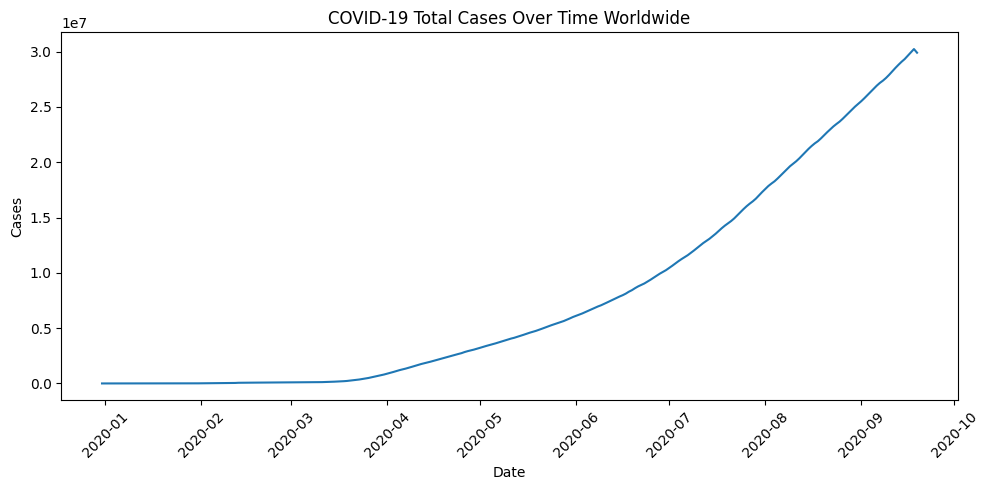

In [4]:
# how did total cases grow globally over time?
cases_time = df.groupby('date')['total_cases'].sum()
plt.figure(figsize=(10, 5))
plt.plot(cases_time)
plt.title('COVID-19 Total Cases Over Time Worldwide')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

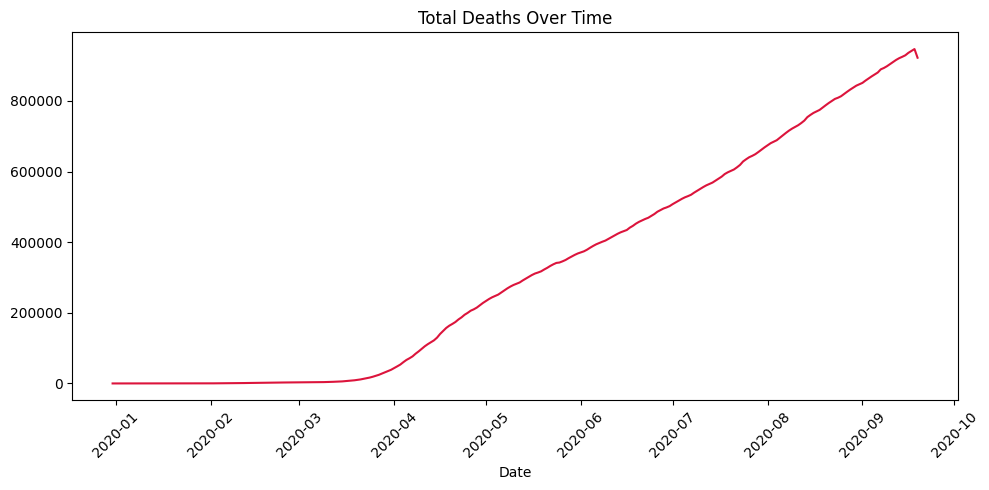

In [5]:
# deaths tell a different story than cases
# early waves killed more per case before vaccines , treatment and prevention measures
deaths_over_time = df.groupby('date')['total_deaths'].sum()
plt.figure(figsize=(10, 5))
plt.plot(deaths_over_time, color='crimson')
plt.title('Total Deaths Over Time')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

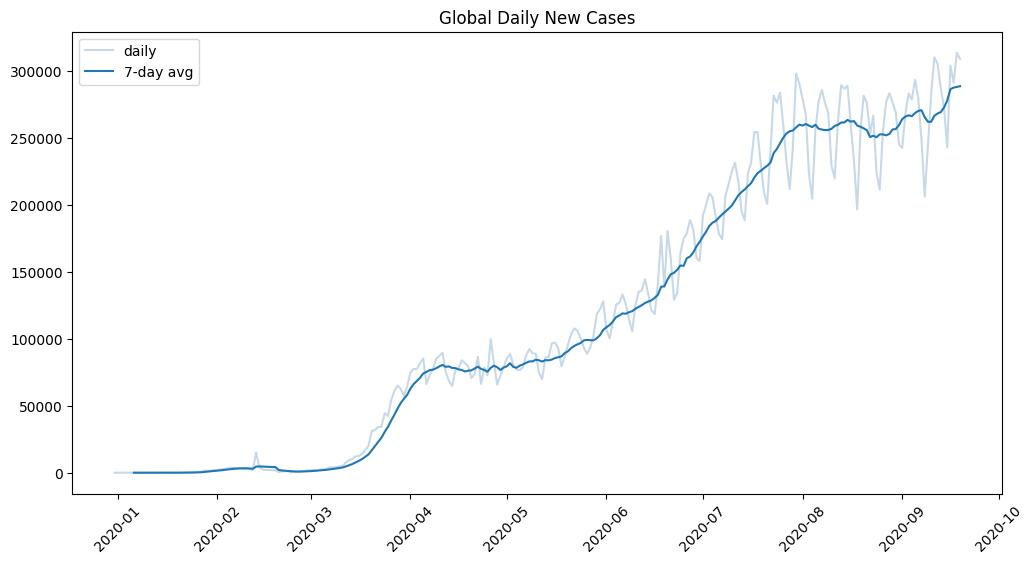

In [6]:
# daily new cases but as the raw numbers are messy and looks outliers i will use rolling avergae
# rolling average makes the actual waves much clearer
daily_new = df.groupby('date')['new_cases'].sum()
rolling = daily_new.rolling(7).mean()
plt.figure(figsize=(12, 6))
plt.plot(daily_new, alpha=0.3, color='steelblue', label='daily')
plt.plot(rolling, label='7-day avg')
plt.title('Global Daily New Cases')
plt.xticks(rotation=45)
plt.legend()
plt.show()

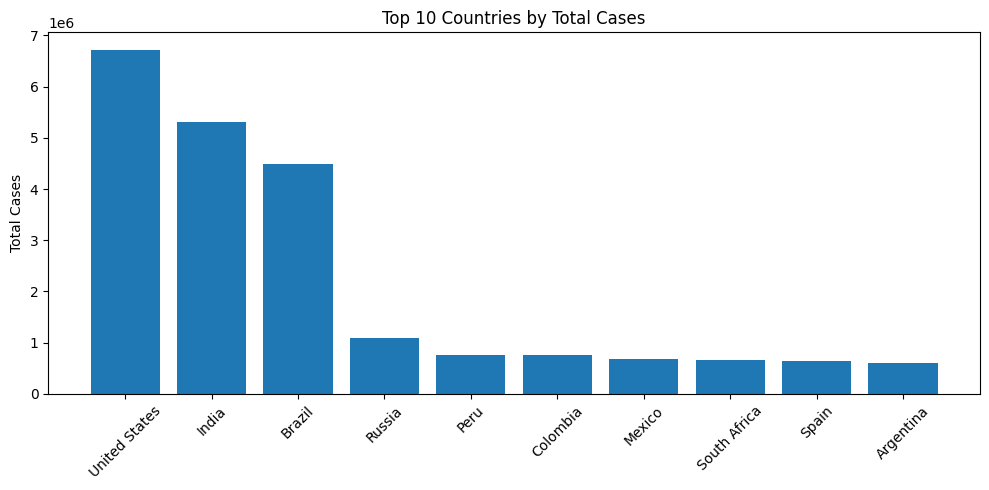

In [7]:
# checking which countries was affected severely
# using the last row per country since total_cases is already cumulative
latest = df.sort_values('date').groupby('location').last().reset_index()
top10 = latest.nlargest(10, 'total_cases')
plt.figure(figsize=(10, 5))
plt.bar(top10['location'], top10['total_cases'])
plt.title('Top 10 Countries by Total Cases')
plt.xticks(rotation=45)
plt.ylabel('Total Cases')
plt.tight_layout()
plt.show()

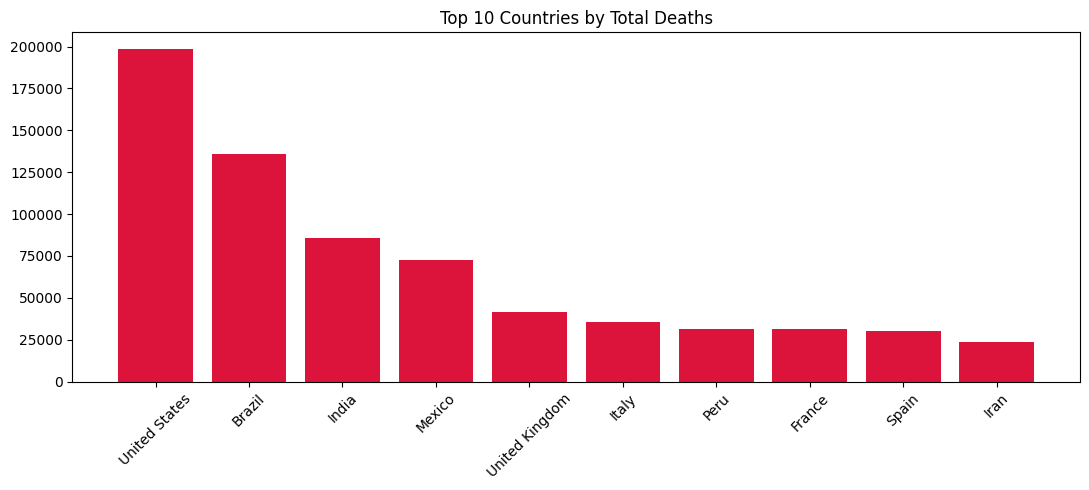

In [8]:
# does the death ranking look the same as the case ranking?
top10DeathCountries = latest.nlargest(10, 'total_deaths')

plt.figure(figsize=(11, 5))
plt.bar(top10DeathCountries['location'], top10DeathCountries['total_deaths'], color='crimson')
plt.title('Top 10 Countries by Total Deaths')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# Brazil and Peru rank higher here than case 

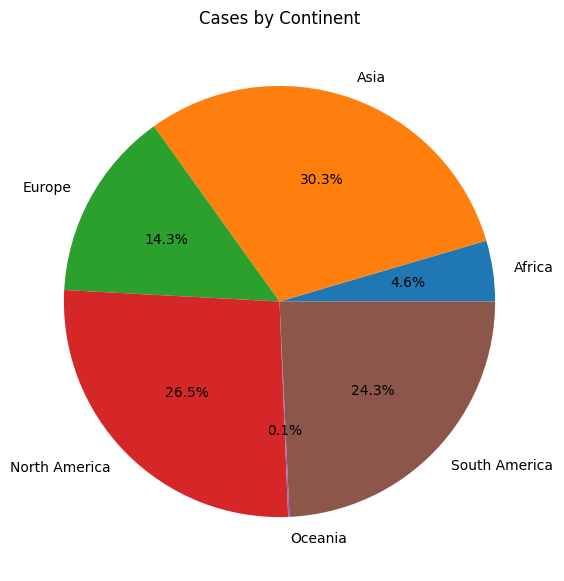

In [9]:
# which continent is affected the most
continent_cases = latest.groupby('continent')['total_cases'].sum()
plt.figure(figsize=(7, 7))
plt.pie(continent_cases.values, labels=continent_cases.index, autopct='%1.1f%%')
plt.title('Cases by Continent')
plt.show()
# The cases in Europe and Asia are high 

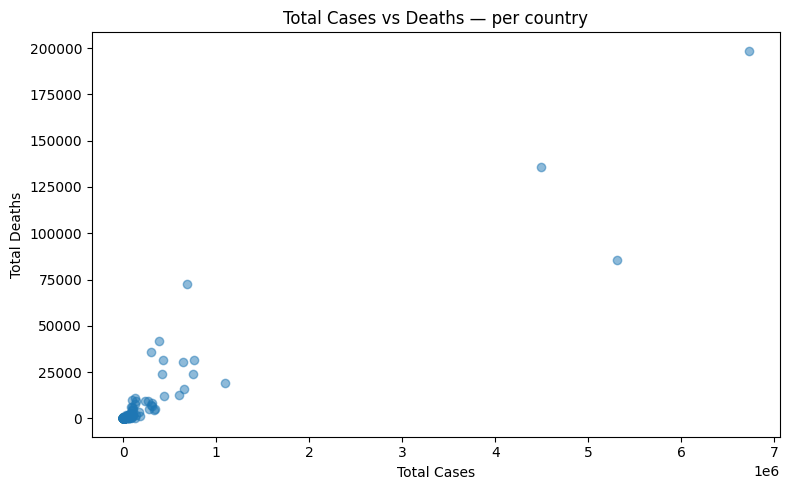

In [10]:
# is there a clear relationship between case count and death count across countries?
scatter_df = latest.dropna(subset=['total_cases', 'total_deaths'])
plt.figure(figsize=(8, 5))
plt.scatter(scatter_df['total_cases'], scatter_df['total_deaths'], alpha=0.5)
plt.title('Total Cases vs Deaths — per country')
plt.xlabel('Total Cases')
plt.ylabel('Total Deaths')
plt.tight_layout()
plt.show()
# mostly linear but there are clear outliers in both data

In [11]:
if 'people_fully_vaccinated' in latest.columns:
    vacc_df = latest.dropna(subset=['people_fully_vaccinated'])
    top_vacc = vacc_df.nlargest(10, 'people_fully_vaccinated')
    plt.figure(figsize=(10, 5))
    plt.bar(top_vacc['location'], top_vacc['people_fully_vaccinated'], color='seagreen')
    plt.title('Top 10 Countries — People Fully Vaccinated')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('no vaccination data in this version')

no vaccination data in this version


In [12]:
print("Total cases:", latest['total_cases'].sum())
print("Total deaths:", latest['total_deaths'].sum())
print("Most affected country:", latest.loc[latest['total_cases'].idxmax(), 'location'])
cfr = latest['total_deaths'].sum() / latest['total_cases'].sum() * 100
print(f"Rough case fatality rate: {cfr:.2f}%")

Total cases: 30539750.0
Total deaths: 952717.0
Most affected country: United States
Rough case fatality rate: 3.12%
